# NB1 — SFT-mini: mô hình SFT tiếng Việt (checkpoint) làm điểm xuất phát cho DPO

**Công nghệ:** Unsloth + LoRA r=16 trên Qwen3-4B-Instruct-2507 (4-bit) + 1k VN Alpaca, 1 epoch.

> **Mục tiêu:** tạo mô hình SFT để DPO align tiếp. Notebook lưu hai thứ:
> - `adapters/sft-mini/`: LoRA adapter (nhẹ, để nộp bài);
> - `models/sft-merged/`: SFT đã gộp vào trọng số 16-bit. **NB3 huấn luyện DPO trên mô hình này**,
>   nên reference của DPO chính là mô hình SFT (lab cũ dùng nhầm mô hình gốc làm reference).
>
> Mô hình gốc đã là bản instruct, nên SFT ở đây chủ yếu kéo phong cách trả lời về
> tiếng Việt kiểu Alpaca. Loss chỉ tính trên phần trả lời (`train_on_responses_only`).

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "lab22" / "config.py").exists())
sys.path.insert(0, str(ROOT))

import unsloth  # noqa: F401  (must load before trl/transformers)
import torch

from lab22 import config as C
from lab22 import modeling as MD

assert torch.cuda.is_available(), "NB1 needs a CUDA GPU. See HARDWARE-GUIDE.md."
C.ensure_dirs()
print(C.summary())

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!


COMPUTE_TIER=T4 base=unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit max_len=768 seed=42
SFT saillab/alpaca-vietnamese-cleaned[:1000]  PREF sailor2/sea-ultrafeedback-onpolicy (Vietnamese) train=800 eval=100
DPO beta=0.1 lr=5e-06 epochs=1.0 loss=['sigmoid']


## 1. Nạp mô hình 4-bit + LoRA

In [2]:
model, tokenizer = MD.load_model(C.BASE_MODEL)
model = MD.add_lora(model)
print(f"pad={tokenizer.pad_token!r} eos={tokenizer.eos_token!r}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

==((====))==  Unsloth 2026.10.2: Fast Qwen3 patching. Transformers: 5.17.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Unsloth 2026.10.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


pad='<|vision_pad|>' eos='<|im_end|>'
Trainable params: 33,030,144


## 2. VN Alpaca → chat text

In [3]:
from datasets import load_dataset

ds = load_dataset(C.SFT_DATASET, split=f"train[:{C.SFT_SLICE}]")
print(f"Loaded {len(ds)} rows. Columns: {ds.column_names}")


def to_text(row):
    # The translated rows carry stray leading spaces; strip so the template stays clean.
    instruction, extra = row["instruction"].strip(), (row.get("input") or "").strip()
    prompt = instruction + (f"\n\n{extra}" if extra else "")
    messages = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": row["output"].strip()},
    ]
    return {"text": MD.chat_text(tokenizer, messages, add_generation_prompt=False)}


ds = ds.filter(lambda r: bool(r.get("instruction")) and bool(r.get("output")))
ds = ds.map(to_text, remove_columns=ds.column_names)
print(ds[0]["text"][:400])

README.md:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

data/train-00000-of-00001-4b184a9550bbb0(…): reconstructing file:   0%|          |  0.00B / 22.1MB            

data/train-00000-of-00001-4b184a9550bbb0(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-03703bd28914fad(…): reconstructing file:   0%|          |  0.00B / 5.61MB            

data/test-00000-of-00001-03703bd28914fad(…): downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/10401 [00:00<?, ? examples/s]

Loaded 1000 rows. Columns: ['instruction', 'input', 'output']


Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

<|im_start|>user
Đưa ra một mô tả về một con vật, xác định loại động vật đó là gì.

Loài vật này có chiếc cổ dài, linh hoạt và mỏ hẹp, nhọn. Nó có chân dài và bàn chân có màng, và nó ăn chủ yếu là cá.<|im_end|>
<|im_start|>assistant
<think>

</think>

Con vật được mô tả có khả năng là một con diệc.<|im_end|>



## 3. Huấn luyện (loss chỉ trên phần trả lời)

In [4]:
from trl import SFTConfig, SFTTrainer
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=ds,
    args=SFTConfig(
        output_dir=str(C.ADAPTERS / "sft-checkpoints"),
        dataset_text_field="text",
        max_length=C.MAX_LEN,
        per_device_train_batch_size=C.TIER.sft_batch,
        gradient_accumulation_steps=C.TIER.sft_grad_accum,
        num_train_epochs=1,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_steps=0.03,
        logging_steps=10,
        save_strategy="no",
        optim="adamw_8bit",
        seed=C.SEED,
        report_to="none",
        **MD.precision_flags(),
    ),
)
# Qwen ChatML markers; prompt tokens get label -100.
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user\n",
    response_part="<|im_start|>assistant\n",
)
result = trainer.train()
print(f"Final SFT loss: {result.training_loss:.4f}")

import json
from datetime import datetime, timezone

(C.EVAL_DIR / "sft_metrics.json").write_text(json.dumps({
    "gpu": torch.cuda.get_device_name(0),
    "vram_gb": torch.cuda.get_device_properties(0).total_memory / 1e9,
    "base_model": C.BASE_MODEL, "dataset": C.SFT_DATASET,
    "n_train": len(ds), "epochs": 1, "max_len": C.MAX_LEN,
    "seed": C.SEED, "train_runtime": result.metrics.get("train_runtime"),
    "final_loss": float(result.training_loss),
    "logs": trainer.state.log_history,
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
}, ensure_ascii=False, indent=2), encoding="utf-8")

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 1 | Total steps = 125
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,1.884192
20,1.393450
30,1.417083
40,1.303915
50,1.326071
60,1.399122
70,1.290137
80,1.295847
90,1.252454
100,1.277261


Final SFT loss: 1.3602


2658

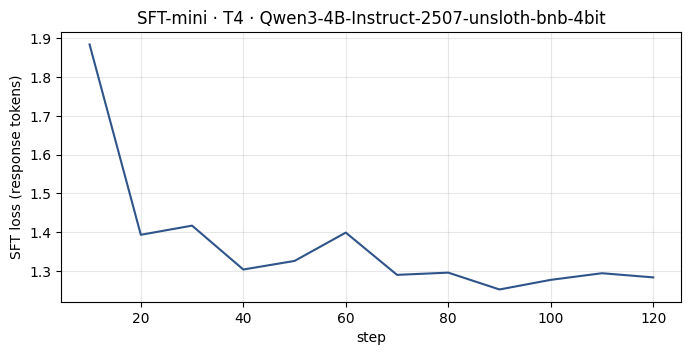

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

logs = pd.DataFrame([r for r in trainer.state.log_history if "loss" in r])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(logs["step"], logs["loss"], color="#2e548a")
ax.set_xlabel("step")
ax.set_ylabel("SFT loss (response tokens)")
ax.set_title(f"SFT-mini · {C.COMPUTE_TIER} · {C.BASE_MODEL.split('/')[-1]}")
ax.grid(True, alpha=0.3)
C.SCREENSHOTS.mkdir(parents=True, exist_ok=True)
fig.savefig(C.SCREENSHOTS / "02-sft-loss.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Lưu adapter + mô hình SFT đã gộp

In [6]:
model.save_pretrained(str(C.SFT_ADAPTER))
tokenizer.save_pretrained(str(C.SFT_ADAPTER))
model.save_pretrained_merged(str(C.SFT_MERGED), tokenizer, save_method="merged_16bit")
print(f"Saved adapter → {C.SFT_ADAPTER}\nSaved merged 16-bit → {C.SFT_MERGED}")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Lab22_PhamHoangTrong_2A202602765/adapters/sft-mini/tokenizer_config.json.


config.json:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/32.9k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Lab22_PhamHoangTrong_2A202602765/models/sft-merged/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...

Unsloth: Merging weights into 16bit:  50%|█████     | 1/2 [01:45<01:45, 105.85s/it]

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [03:07<00:00, 91.85s/it] 

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [03:07<00:00, 93.95s/it]

Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/Lab22_PhamHoangTrong_2A202602765/models/sft-merged`


Saved adapter → /content/drive/MyDrive/Lab22_PhamHoangTrong_2A202602765/adapters/sft-mini
Saved merged 16-bit → /content/drive/MyDrive/Lab22_PhamHoangTrong_2A202602765/models/sft-merged


In [7]:
sample = MD.generate(model, tokenizer, ["Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào."], 200)
print(sample[0])

Both `max_new_tokens` (=200) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


</tool_call>

</tool_call>

Quicksort là một thuật toán sắp xếp phân chia và chiếm ưu thế. Nó hoạt động bằng cách chọn một phần tử làm trục và sắp xếp các phần tử khác thành hai nhóm: các phần tử nhỏ hơn trục và các phần tử lớn hơn trục. Sau đó, thuật toán đệ quy áp dụng quy trình này cho các nhóm nhỏ hơn cho đến khi tất cả các phần tử được sắp xếp.


## 5. Ghi chú vibe-coding

> **Cần bao nhiêu SFT để DPO có ý nghĩa?** Thử `SFT_SLICE=100` rồi chạy lại NB1 → NB3.
> Margin ở NB3 còn tăng không? Câu trả lời còn mạch lạc không? Ghi giả thuyết trước
> khi chạy, kết quả vào `submission/REFLECTION.md` §6.

**Tiếp theo:** NB2 — dữ liệu sở thích (preference) tiếng Việt.